In [1]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
print("Unika labels:", np.unique(y_train_full))

print("Minsta pixelvärde:", X_train_full.min())
print("Största pixelvärde:", X_train_full.max())

Unika labels: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


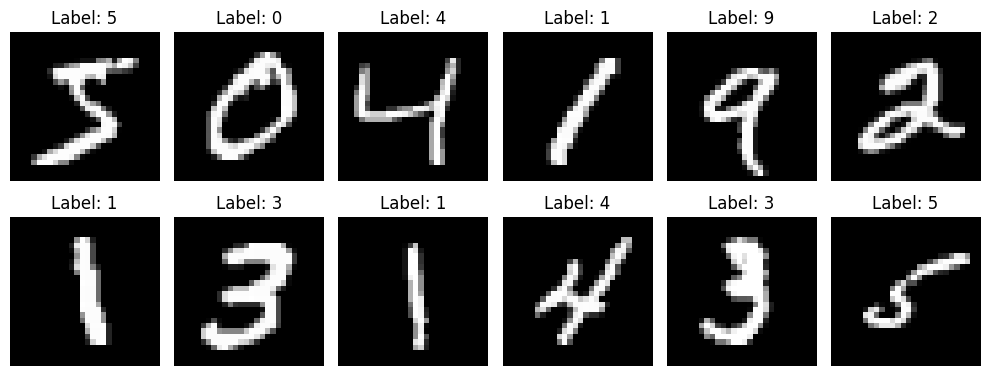

In [9]:
plt.figure(figsize=(10,4))

for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(f"Label: {y_train_full[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [11]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


print("Minsta värde efter normalisering:", X_train.min())
print("Största värde efter normalisering:", X_train.max())

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0


In [12]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


In [13]:
print("Exempel på labels:", y_train[:10])

Exempel på labels: [2 1 5 1 8 0 8 7 1 1]


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9480 - loss: 0.1715 - val_accuracy: 0.9792 - val_loss: 0.0830
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9842 - loss: 0.0508 - val_accuracy: 0.9825 - val_loss: 0.0725
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9889 - loss: 0.0349 - val_accuracy: 0.9840 - val_loss: 0.0607
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9917 - loss: 0.0255 - val_accuracy: 0.9845 - val_loss: 0.0588
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9949 - loss: 0.0178 - val_accuracy: 0.9863 - val_loss: 0.0611


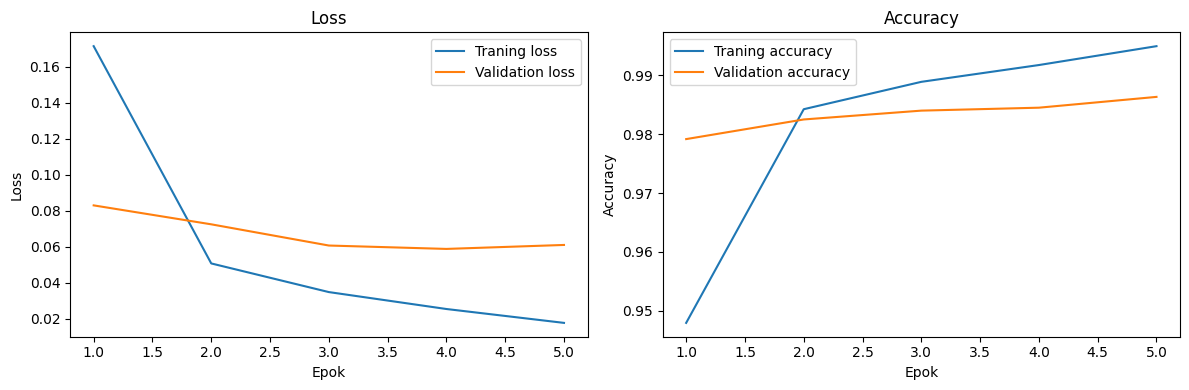

In [20]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.0386
Test accuracy: 0.9877


In [27]:
n_images = 25

X_new = X_test[:n_images]
y_true = y_test[:n_images]

y_proba = model.predict(X_new)

y_pred = np.argmax(y_proba, axis=1)

print("Sanna labels:       ", y_true)
print("Predikterade labels:", y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sanna labels:        [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4]
Predikterade labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4]


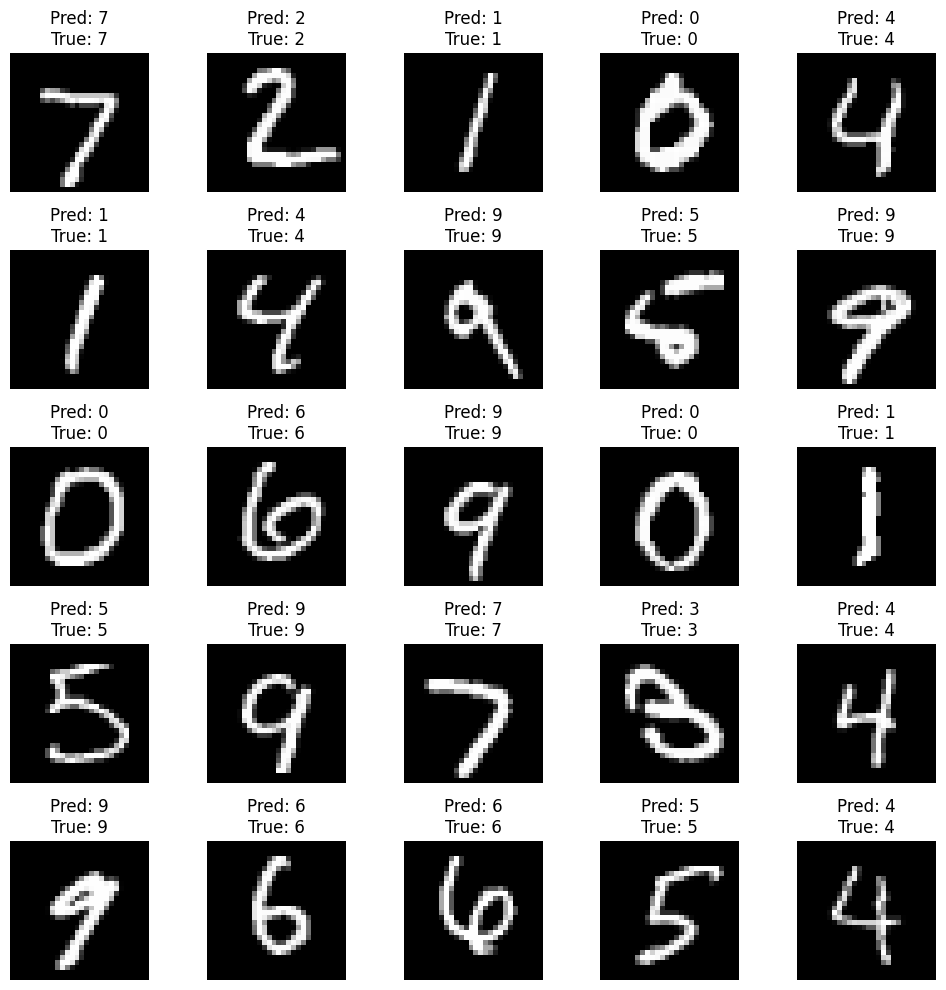

In [29]:
plt.figure(figsize=(10, 10))

for i in range(n_images):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_new[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_true[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
image_index = 18

probabilities = pd.DataFrame({
    "Klass": range(10),
    "Sannolikhet": y_proba[image_index]
})

probabilities = probabilities.sort_values(
    by="Sannolikhet",
    ascending=False
)

probabilities["Sannolikhet %"] = (probabilities["Sannolikhet"] * 100).round(2)

probabilities["Sannolikhet"] = probabilities["Sannolikhet"].round(6)

print("Sann label:", y_true[image_index])
print("Predikterad label:", y_pred[image_index])
display(probabilities[["Klass", "Sannolikhet %", "Sannolikhet"]])

Sann label: 3
Predikterad label: 3


,Klass,Sannolikhet %,Sannolikhet
3,3,72.790001,0.727929
8,8,26.129999,0.261316
2,2,0.650000,0.006534
5,5,0.420000,0.004212
0,0,0.000000,0.000005
6,6,0.000000,0.000005
9,9,0.000000,0.000000
1,1,0.000000,0.000000
7,7,0.000000,0.000000
4,4,0.000000,0.000000


In [34]:
model.save("mnist_cnn_model.keras")

In [35]:
loaded_model = keras.models.load_model("mnist_cnn_model.keras")

loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Laddad modell - test loss: {loaded_test_loss:.4f}")
print(f"Laddad modell - test accuracy: {loaded_test_accuracy:.4f}")

Laddad modell - test loss: 0.0386
Laddad modell - test accuracy: 0.9877
